# The goal of this notebook is to rigorously test the component spawning mechanism of the OAMFA system

#### Data
The images are fetched from the HYPSO Portal, and the following images are used: 
- HYPSO-1_HSI_20220529T190459Z-l1a.nc (Training + Testing), this is an image taken from svarlbard that contains two classes (Ice and ocean)
- HYPSO-1_HSI_20230615T094801Z-l1a.nc (Forest pixels), this image contains pixels from a forest

**Training data**\
Trainingdata consists of the first 10 rows from the svarlbard-image. These rows contains both ice and ocean, and thus they should capture most of the signal in the image. The trianingdata contains a total of 6840 pixels.\

**Test data**\
Testdata consists of the remainding 956 rows, for a total of 647,064 pixels. Into the training-data, a square of 100x100 pixels is inserted.\
In the *component spawning* testcase, the square contains forrest-pixels taken from a forrest in norway. PCA is used to determine that ~90% of the variance can be explained in two PCs, and this is used as an indicator that the square contains pixels from one "material".\
In the *noise rejection* testcase, the square is drawn from random gaussian noise.   

#### Streaming
The pretrained MFA will stream the pixels row by row, and assign them to either one of the existinf factors, or the outlier-shelf. The assignment is colour-coded. 


#### Wanted behaviour in the of two tests
**Novel Material Spawning**: Expected outcome is for the model to spawn one new component.\
**Noise Rejection**: Expected outcome is for the model to spawn zero new components.

#### Plotting
Transpose the test-image; in this way, the x-axis is the height, and in some sense represents time since each unit forward is a new line from the pushbrome sensor. I want three plots:

1) The raw coloured image. A dotted red line at h=40 represents the device between the training and test image. The outlier-square should also be there
2) The slice-wise assignment of classes. For each slice, we assign each pixel to a class and colour it thereafter. Outliers should have their own colour. I want a dotted line at the slice where the new cluster was spawned.
3) The Mahalanobis distance for each pixel at each timeframe. This should be a heatmap. Also, this plot should mark where the new pixel has spawned. 



In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import glob
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2
import copy


parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from otfp import MFA_OTFP
from hypso import Hypso


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_data_dir = glob.glob(f'../data/component_spawning/*.nc')

If the test-images are not created: create them

The images are fetched from the HYPSO Portal, and the following are used: 
- HYPSO-1_HSI_20220529T190459Z-l1a.nc (Training + Testing, the image is )
- HYPSO-1_HSI_20230615T094801Z-l1a.nc (Forest pixels)

Successfully loaded svalbard_2022-05-29T19-04-59Z-l1b.nc | Shape: (956, 684, 120)
Successfully loaded mjosa_forest_2023-06-15T09-48-01Z-l1b.nc | Shape: (598, 1092, 120)
Splitting primary image:
New Train Shape: (20, 684, 120)
New Test Shape: (936, 684, 120)
Forest Source Shape: (598, 1092, 120)


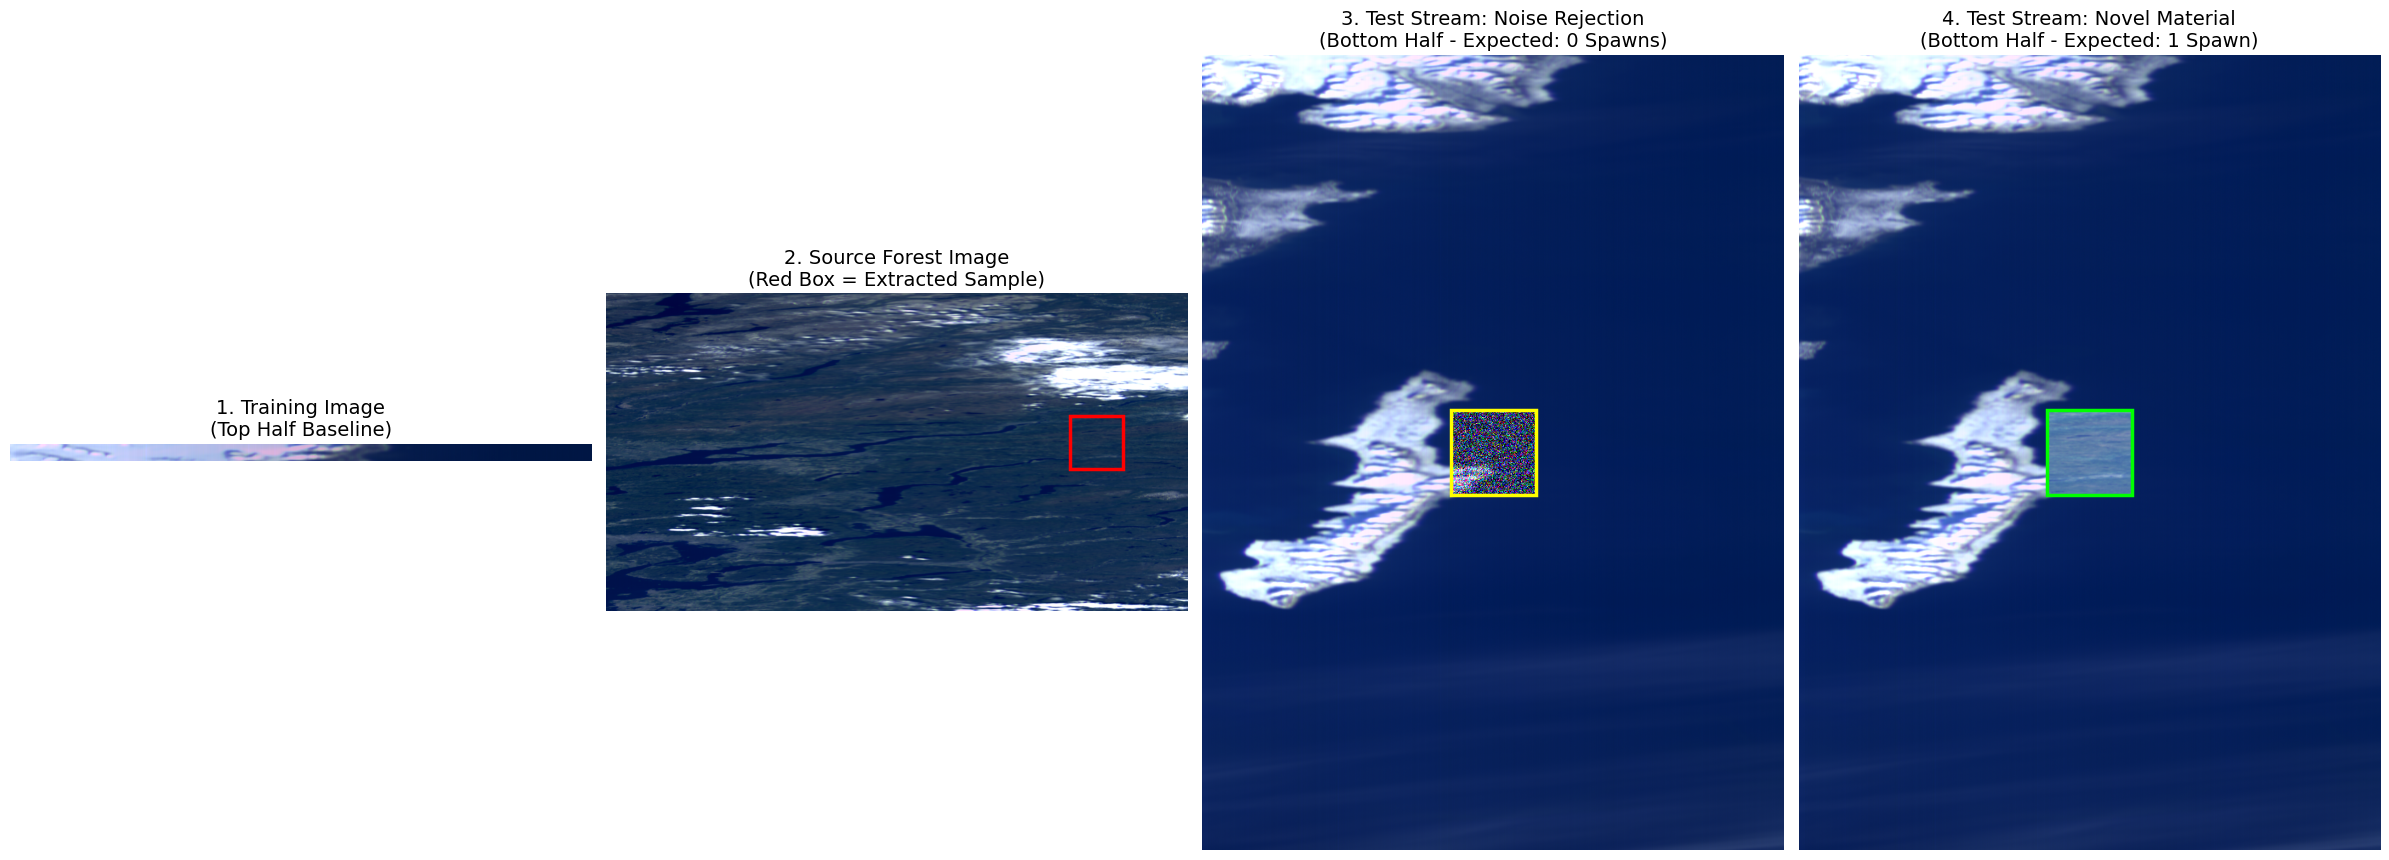

In [2]:

# We now only need the primary Svalbard image and the Forest image
base_svalbard_path = "../data/component_spawning/svalbard_2022-05-29T19-04-59Z-l1b.nc"
forest_path = "../data/component_spawning/mjosa_forest_2023-06-15T09-48-01Z-l1b.nc"

path_list = [base_svalbard_path, forest_path]
data_dict = {}

# --- 1. Fetch the Images ---
for file_path in path_list:
    try:
        satobj = Hypso(file_path)
        cube = getattr(satobj, "l1b_cube", None)
        if cube is None:
            print(f"Skipping {file_path}: Missing l1b_cube data.")
            continue
        
        image = cube.values.astype(np.float32)
        data_dict[file_path] = image
        print(f"Successfully loaded {file_path.split('/')[-1]} | Shape: {image.shape}")
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        break

# Extract the arrays
svalbard_full = data_dict.get(base_svalbard_path)
img_forest = data_dict.get(forest_path)

# Proceed only if data successfully loaded
if svalbard_full is not None and img_forest is not None:

    # --- 1.5 The Split ---
    # Split the Svalbard image horizontally (top half for training, bottom half for testing)
    
    img_train = svalbard_full[:20, :, :]
    img_test_base = svalbard_full[20:, :, :] 
    
    print(f"Splitting primary image:")
    print(f"New Train Shape: {img_train.shape}")
    print(f"New Test Shape: {img_test_base.shape}")
    print(f"Forest Source Shape: {img_forest.shape}")

    # --- Helper Function: Hyperspectral to RGB ---
    def get_rgb(hsi_cube):
        """Extracts RGB, normalizes globally to preserve color balance, and applies gamma correction."""
        r, g, b = hsi_cube[:, :, 70], hsi_cube[:, :, 50], hsi_cube[:, :, 20]
        rgb = np.stack([r, g, b], axis=-1)
        
        p_low = np.nanpercentile(rgb, 2)
        p_high = np.nanpercentile(rgb, 98)
        rgb_norm = (rgb - p_low) / (p_high - p_low + 1e-8)
        rgb_clipped = np.clip(rgb_norm, 0, 1)
        
        gamma = 0.8
        rgb_gamma = rgb_clipped ** gamma
        
        return rgb_gamma

    # 2. Setup Patch Coordinates
    PATCH_SIZE = 100
    
    # Where to sample FROM in the forest image
    f_row, f_col = 230, 870 
    
    # Dynamically center the insertion box inside the testing half
    t_row = (img_test_base.shape[0] - PATCH_SIZE) // 2
    t_col = (img_test_base.shape[1] - PATCH_SIZE) // 2

    # 3. Extract the Forest Sample
    forest_patch = img_forest[f_row:f_row+PATCH_SIZE, f_col:f_col+PATCH_SIZE, :].copy()

    # 4. Create the Two Test Scenarios
    
    # A) Novel Material Spawning (Forest injected into Test Image)
    test_img_forest = img_test_base.copy()
    test_img_forest[t_row:t_row+PATCH_SIZE, t_col:t_col+PATCH_SIZE, :] = forest_patch
    
    # B) Noise Rejection (Gaussian White Noise injected into Test Image)
    test_img_noise = img_test_base.copy()
    noise_patch = test_img_noise[t_row:t_row+PATCH_SIZE, t_col:t_col+PATCH_SIZE, :].copy()
    
    np.random.seed(42) 
    # Add Gaussian white noise across all bands to destroy the spectral angle
    gaussian_noise = np.random.normal(loc=0.0, scale=np.nanstd(img_test_base) * 2, size=noise_patch.shape)
    noise_patch = noise_patch + gaussian_noise
    
    # Clip it to keep it within realistic sensor boundaries
    test_img_noise[t_row:t_row+PATCH_SIZE, t_col:t_col+PATCH_SIZE, :] = np.clip(noise_patch, 0, np.nanmax(img_test_base))

    # 5. Plotting the Validation Grid
    fig, axes = plt.subplots(1, 4, figsize=(24, 16))
    
    # Plot 1: Pre-training Image
    axes[0].imshow(get_rgb(img_train))
    axes[0].set_title("1. Training Image\n(Top Half Baseline)", fontsize=14)
    axes[0].axis('off')
    
    # Plot 2: Source Forest Image
    axes[1].imshow(get_rgb(img_forest))
    axes[1].set_title("2. Source Forest Image\n(Red Box = Extracted Sample)", fontsize=14)
    rect_source = patches.Rectangle((f_col, f_row), PATCH_SIZE, PATCH_SIZE, 
                                    linewidth=2.5, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect_source)
    axes[1].axis('off')
    
    # Plot 3: Noise Rejection Test
    axes[2].imshow(get_rgb(test_img_noise))
    axes[2].set_title("3. Test Stream: Noise Rejection\n(Bottom Half - Expected: 0 Spawns)", fontsize=14)
    rect_noise = patches.Rectangle((t_col, t_row), PATCH_SIZE, PATCH_SIZE, 
                                   linewidth=2.5, edgecolor='yellow', facecolor='none')
    axes[2].add_patch(rect_noise)
    axes[2].axis('off')
    
    # Plot 4: Novel Material Test
    axes[3].imshow(get_rgb(test_img_forest))
    axes[3].set_title("4. Test Stream: Novel Material\n(Bottom Half - Expected: 1 Spawn)", fontsize=14)
    rect_target = patches.Rectangle((t_col, t_row), PATCH_SIZE, PATCH_SIZE, 
                                    linewidth=2.5, edgecolor='lime', facecolor='none')
    axes[3].add_patch(rect_target)
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Data loading failed. Check your file paths and Hypso class configuration.")

### Determining the number of signatures in the sampled forest patch

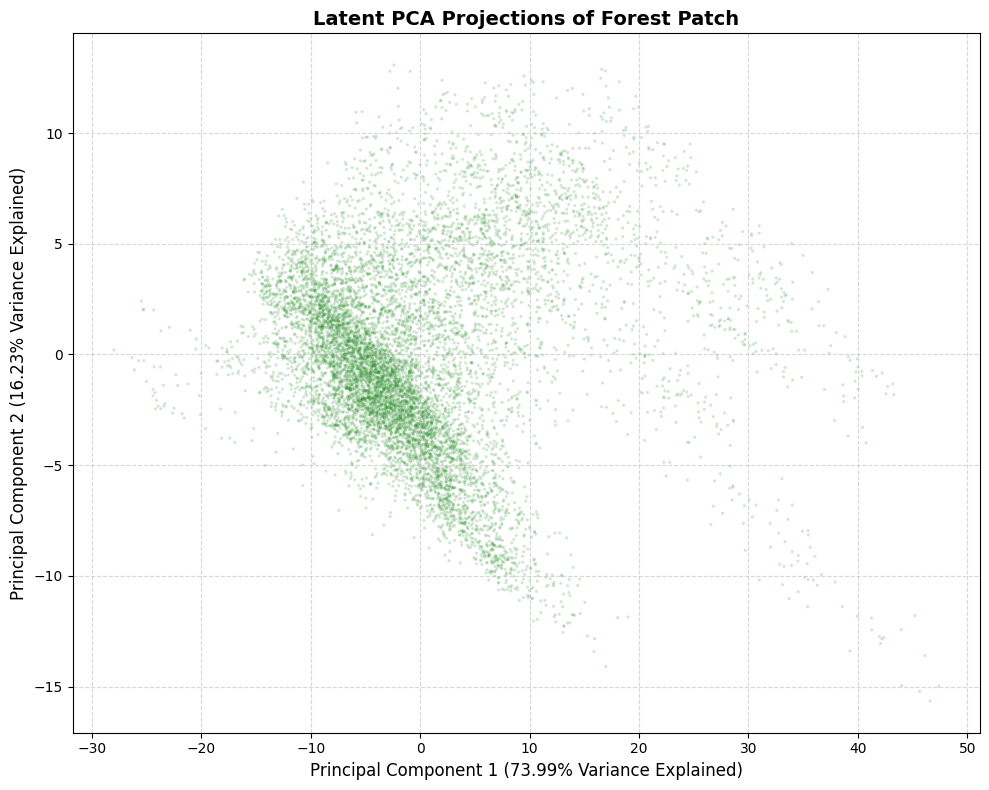

In [3]:
# Forrest-patch is fetched from the above cell

h, w, bands = forest_patch.shape
num_pixels = h * w

# Flatten from 3D (128, 128, B) to 2D (16384, B)
flattened_pixels = forest_patch.reshape(num_pixels, bands)

# Optional but recommended: Standardize the features (bands)
# This ensures bands with larger numerical ranges don't dominate the PCA
scaler = StandardScaler()
scaled_pixels = scaler.fit_transform(flattened_pixels)

# --- 2. Fit the PCA model ---
# We only need 2 components for a 2D scatter plot
pca = PCA(n_components=2)
latent_projections = pca.fit_transform(scaled_pixels)

# --- 3. Extract Explained Variance ---
# Convert the ratios to percentages for the plot labels
explained_variance = pca.explained_variance_ratio_ * 100
var_pc1 = explained_variance[0]
var_pc2 = explained_variance[1]

# --- 4. Plot the Latent Projections ---
plt.figure(figsize=(10, 8))

# Using a low 'alpha' (transparency) is crucial here. 
# You are plotting 16,384 points, and they will overplot into a solid blob otherwise.
plt.scatter(
    latent_projections[:, 0], 
    latent_projections[:, 1], 
    alpha=0.2,   # Transparency to see density
    s=5,         # Small dot size
    c='forestgreen',
    edgecolors='none'
)

# Labeling with the captured variance
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}% Variance Explained)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}% Variance Explained)', fontsize=12)
plt.title('Latent PCA Projections of Forest Patch', fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Training and initializing the becnhline OAMFA

In [4]:
# Initialize the OAMFA model
print(f"Type of img_train: {type(img_train)}")
if img_train is None:
    print("Warning: img_train failed to load!")

# Your original code:
img_train = img_train.reshape(-1, img_train.shape[-1])  # Flatten to (num_pixels, num_bands)

MFA_OTFP_model=MFA_OTFP(
    init_data=torch.tensor(img_train, dtype=torch.float32),
    n_channels=120, 
    device="cpu", 
    outlier_update_treshold=1000,
    q_max=6,
    K_max=5,
    L2_normalization=True
)

Type of img_train: <class 'numpy.ndarray'>
Starting Bayesian model selection with K_max=5, q_max=6...
Theoretical Chi-Square threshold initialized: 186.33
Finished setup of OTFP-MFA: K=2, q=4


## Test nr 1 *Novel Material Spawning*

First we stream the pretrained model on the unseen data

In [5]:
print("--- INITIALIZING NOVEL MATERIAL TEST ---")

# 1. Clone the pretrained model to keep the original intact
print("Deepcopying the pretrained OAMFA model...")
test_nr1_model = copy.deepcopy(MFA_OTFP_model)

baseline_k = test_nr1_model.MFA.K
print(f"Baseline Components (K): {baseline_k}")

h, w, d = test_img_forest.shape
device = test_nr1_model.device 

print(f"Streaming hyperspectral data (Shape: {test_img_forest.shape})")
test_nr1_model.MFA.train() 

# --- 2. Initialize 2D Maps for the Plotting ---
# --- 2. Initialize 2D Maps for the Plotting ---
assignment_map = np.zeros((h, w))
mahalanobis_map = np.zeros((h, w))

# FIX: Change to a list to track EVERY row where a spawn happens
spawn_rows = [] 
current_k = baseline_k

# --- 3. Stream the data block-by-block ---
for t_row in range(0, h):
    slice_data = test_img_forest[t_row : t_row + 1, :, :]
    batch_flat = slice_data.reshape(-1, d)
    batch_tensor = torch.tensor(batch_flat, dtype=torch.float32).to(device)
    
    # Unpack the 3 variables returned by your updated otfp.py
    assignments, distances, _ = test_nr1_model.process_data_block(X=batch_tensor)
    
    # Move to CPU/NumPy
    assign_np = assignments.cpu().numpy().copy()
    dist_np = distances.cpu().numpy()
    
    # Manually mask outliers as -1 so they render as black in the plot
    outlier_mask = dist_np > test_nr1_model.chi2_threshold
    assign_np[outlier_mask] = -1
    
    # Store in the 2D maps
    assignment_map[t_row, :] = assign_np
    mahalanobis_map[t_row, :] = dist_np
    
    # FIX: Append to the list every time K increases
    if test_nr1_model.MFA.K > current_k:
        spawn_rows.append(t_row)
        current_k = test_nr1_model.MFA.K

print("\n--- STREAMING COMPLETE ---")
final_k = test_nr1_model.MFA.K
print(f"Final Components (K): {final_k}")
print(f"Total New Components Spawned: {final_k - baseline_k}")
if spawn_rows:
    print(f"New components spawned at push-broom rows: {spawn_rows}")

--- INITIALIZING NOVEL MATERIAL TEST ---
Deepcopying the pretrained OAMFA model...
Baseline Components (K): 2
Streaming hyperspectral data (Shape: (936, 684, 120))
Model successfully updated! Total components (K) is now 3

Successfully birthed 1 new components this cycle.
Model successfully updated! Total components (K) is now 4

Successfully birthed 1 new components this cycle.

--- STREAMING COMPLETE ---
Final Components (K): 4
Total New Components Spawned: 2
New components spawned at push-broom rows: [427, 475]


Text(0, 0.5, 'Pixel Width')

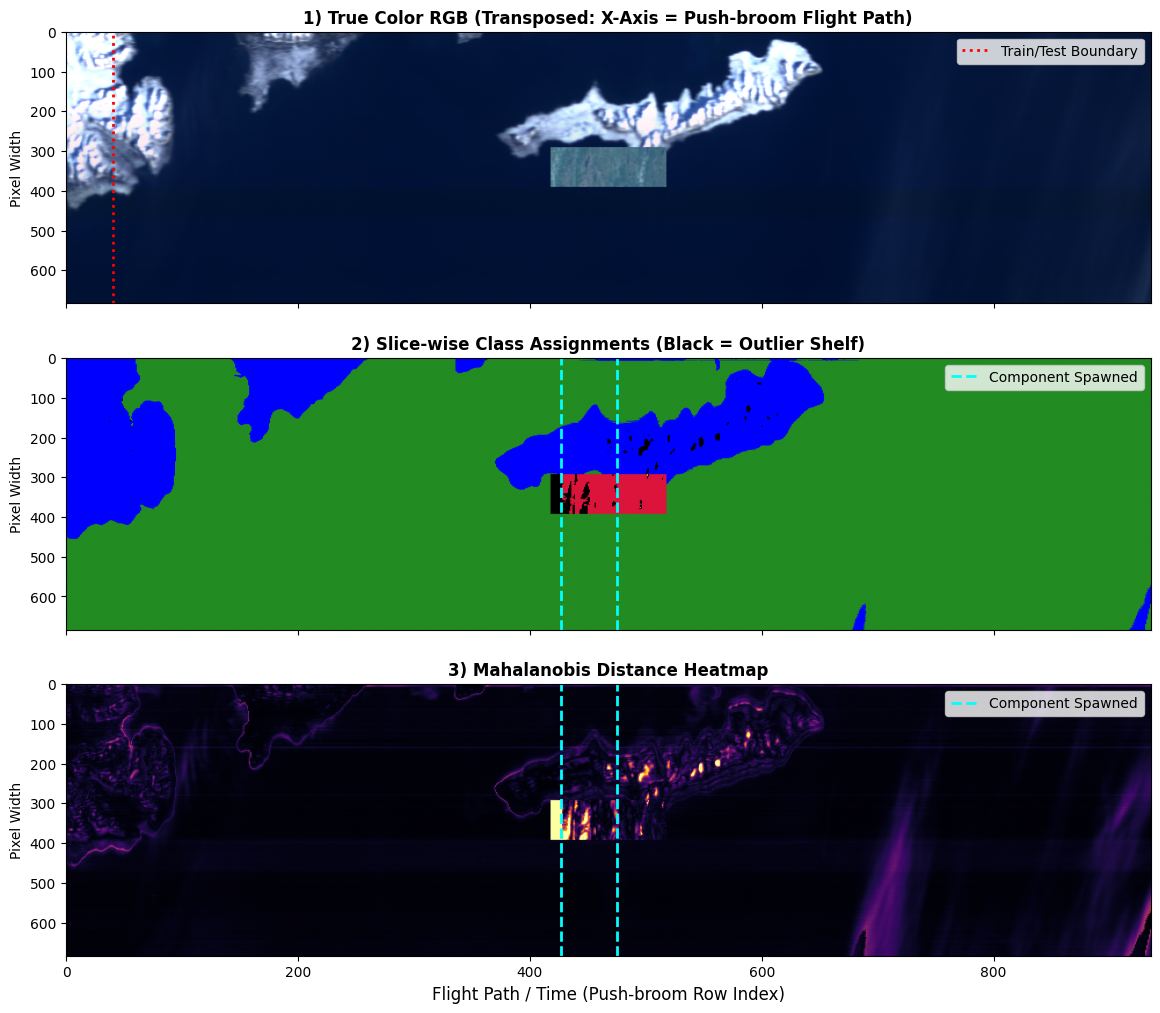

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap

# Create 3 stacked subplots that share the same X-axis (Time/Flight Path)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Define Colormap: -1=Black (Outlier), 0=Blue, 1=Green, 2=Red (Novel), etc.
cmap_classes = ListedColormap(['black', 'blue', 'forestgreen', 'crimson', 'orange', 'purple'])
cmap_classes.set_bad('white', 1.0) # Fallback for NaNs

# --- PRE-COMPUTE RGB IMAGE ---
# Select 3 bands to represent Red, Green, and Blue
r_band, g_band, b_band = 70, 50, 30  # Adjust these to HYPSO-1's actual visible wavelengths
rgb_cube = test_img_forest[:, :, [r_band, g_band, b_band]]

# Normalize the RGB image to [0, 1] so matplotlib can display it.
# Pro-tip: Using the 2nd and 98th percentiles prevents bright sensor spikes from washing out the image.
p2, p98 = np.percentile(rgb_cube, (2, 98))
rgb_normalized = np.clip((rgb_cube - p2) / (p98 - p2 + 1e-8), 0, 1)

# Transpose the spatial dimensions from (Rows, Cols, 3) to (Cols, Rows, 3)
# This keeps the 3 RGB channels intact while flipping the X and Y axes
rgb_transposed = np.swapaxes(rgb_normalized, 0, 1)


# --- Plot 1: Raw Image (Transposed) ---
ax1 = axes[0]
ax1.imshow(rgb_transposed, aspect='auto')

# Dotted red line at training/test split (h=40)
ax1.axvline(x=40, color='red', linestyle=':', linewidth=2, label="Train/Test Boundary")

# Draw Outlier Square
# Because we transposed, the original (x, y) coordinates swap to (y, x)
rect = patches.Rectangle((f_row, f_col), 100, 100, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
ax1.add_patch(rect)
ax1.set_title("1) True Color RGB (Transposed: X-Axis = Push-broom Flight Path)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Pixel Width")
ax1.legend(loc="upper right")

# --- Plot 2: Class Assignments (Transposed) ---
ax2 = axes[1]
ax2.imshow(assignment_map.T, cmap=cmap_classes, aspect='auto', vmin=-1.5, vmax=4.5)

# FIX: Loop through all spawn rows
if len(spawn_rows) > 0:
    for i, s_row in enumerate(spawn_rows):
        # Only label the first line to keep the legend clean
        lbl = "Component Spawned" if i == 0 else None
        ax2.axvline(x=s_row, color='cyan', linestyle='--', linewidth=2, label=lbl)
    ax2.legend(loc="upper right")

ax2.set_title("2) Slice-wise Class Assignments (Black = Outlier Shelf)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Pixel Width")

# --- Plot 3: Mahalanobis Distance Heatmap (Transposed) ---
ax3 = axes[2]
vmax_heat = test_nr1_model.chi2_threshold * 2 
im3 = ax3.imshow(mahalanobis_map.T, cmap='inferno', aspect='auto', vmin=0, vmax=vmax_heat)

# FIX: Loop through all spawn rows here as well
if len(spawn_rows) > 0:
    for i, s_row in enumerate(spawn_rows):
        lbl = "Component Spawned" if i == 0 else None
        ax3.axvline(x=s_row, color='cyan', linestyle='--', linewidth=2, label=lbl)
    ax3.legend(loc="upper right")

ax3.set_title("3) Mahalanobis Distance Heatmap", fontsize=12, fontweight='bold')
ax3.set_xlabel("Flight Path / Time (Push-broom Row Index)", fontsize=12)
ax3.set_ylabel("Pixel Width")

## Test nr2 *Noise Rejection*
First we stream the pretrained model on the unseen data

In [7]:
print("--- INITIALIZING NOVEL MATERIAL TEST ---")

# 1. Clone the pretrained model to keep the original intact
print("Deepcopying the pretrained OAMFA model...")
test_nr2_model = copy.deepcopy(MFA_OTFP_model)

baseline_k = test_nr2_model.MFA.K
print(f"Baseline Components (K): {baseline_k}")

h, w, d = test_img_noise.shape
device = test_nr2_model.device 

print(f"Streaming hyperspectral data (Shape: {test_img_noise.shape})")
test_nr2_model.MFA.train() 

# --- 2. Initialize 2D Maps for the Plotting ---
# --- 2. Initialize 2D Maps for the Plotting ---
assignment_map = np.zeros((h, w))
mahalanobis_map = np.zeros((h, w))

# FIX: Change to a list to track EVERY row where a spawn happens
spawn_rows = [] 
current_k = baseline_k

# --- 3. Stream the data block-by-block ---
for t_row in range(0, h):
    slice_data = test_img_noise[t_row : t_row + 1, :, :]
    batch_flat = slice_data.reshape(-1, d)
    batch_tensor = torch.tensor(batch_flat, dtype=torch.float32).to(device)
    
    # Unpack the 3 variables returned by your updated otfp.py
    assignments, distances, _ = test_nr2_model.process_data_block(X=batch_tensor)
    
    # Move to CPU/NumPy
    assign_np = assignments.cpu().numpy().copy()
    dist_np = distances.cpu().numpy()
    
    # Manually mask outliers as -1 so they render as black in the plot
    outlier_mask = dist_np > test_nr2_model.chi2_threshold
    assign_np[outlier_mask] = -1
    
    # Store in the 2D maps
    assignment_map[t_row, :] = assign_np
    mahalanobis_map[t_row, :] = dist_np
    
    # FIX: Append to the list every time K increases
    if test_nr2_model.MFA.K > current_k:
        spawn_rows.append(t_row)
        current_k = test_nr2_model.MFA.K

print("\n--- STREAMING COMPLETE ---")
final_k = test_nr2_model.MFA.K
print(f"Final Components (K): {final_k}")
print(f"Total New Components Spawned: {final_k - baseline_k}")
if spawn_rows:
    print(f"New components spawned at push-broom rows: {spawn_rows}")

--- INITIALIZING NOVEL MATERIAL TEST ---
Deepcopying the pretrained OAMFA model...
Baseline Components (K): 2
Streaming hyperspectral data (Shape: (936, 684, 120))
Shelf full, but only contained scattered noise. Burning shelf.
Shelf full, but only contained scattered noise. Burning shelf.
Shelf full, but only contained scattered noise. Burning shelf.
Shelf full, but only contained scattered noise. Burning shelf.
Shelf full, but only contained scattered noise. Burning shelf.
Shelf full, but only contained scattered noise. Burning shelf.
Shelf full, but only contained scattered noise. Burning shelf.
Shelf full, but only contained scattered noise. Burning shelf.
Shelf full, but only contained scattered noise. Burning shelf.
Shelf full, but only contained scattered noise. Burning shelf.

--- STREAMING COMPLETE ---
Final Components (K): 2
Total New Components Spawned: 0


Text(0, 0.5, 'Pixel Width')

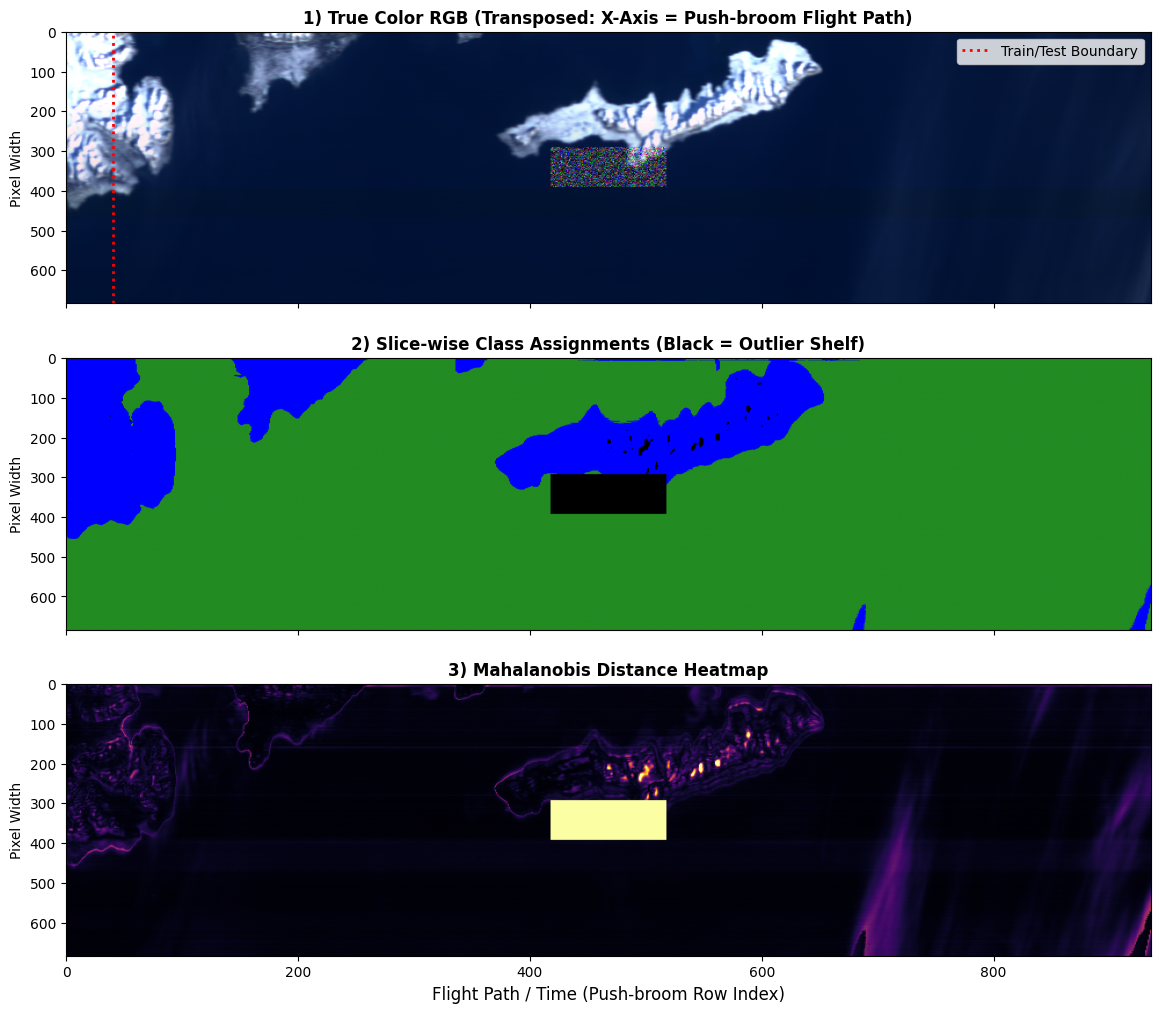

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap

# Create 3 stacked subplots that share the same X-axis (Time/Flight Path)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Define Colormap: -1=Black (Outlier), 0=Blue, 1=Green, 2=Red (Novel), etc.
cmap_classes = ListedColormap(['black', 'blue', 'forestgreen', 'crimson', 'orange', 'purple'])
cmap_classes.set_bad('white', 1.0) # Fallback for NaNs

# --- PRE-COMPUTE RGB IMAGE ---
# Select 3 bands to represent Red, Green, and Blue
r_band, g_band, b_band = 70, 50, 30  # Adjust these to HYPSO-1's actual visible wavelengths
rgb_cube = test_img_noise[:, :, [r_band, g_band, b_band]]

# Normalize the RGB image to [0, 1] so matplotlib can display it.
# Pro-tip: Using the 2nd and 98th percentiles prevents bright sensor spikes from washing out the image.
p2, p98 = np.percentile(rgb_cube, (2, 98))
rgb_normalized = np.clip((rgb_cube - p2) / (p98 - p2 + 1e-8), 0, 1)

# Transpose the spatial dimensions from (Rows, Cols, 3) to (Cols, Rows, 3)
# This keeps the 3 RGB channels intact while flipping the X and Y axes
rgb_transposed = np.swapaxes(rgb_normalized, 0, 1)


# --- Plot 1: Raw Image (Transposed) ---
ax1 = axes[0]
ax1.imshow(rgb_transposed, aspect='auto')

# Dotted red line at training/test split (h=40)
ax1.axvline(x=40, color='red', linestyle=':', linewidth=2, label="Train/Test Boundary")

# Draw Outlier Square
# Because we transposed, the original (x, y) coordinates swap to (y, x)
rect = patches.Rectangle((f_row, f_col), 100, 100, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
ax1.add_patch(rect)
ax1.set_title("1) True Color RGB (Transposed: X-Axis = Push-broom Flight Path)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Pixel Width")
ax1.legend(loc="upper right")

# --- Plot 2: Class Assignments (Transposed) ---
ax2 = axes[1]
ax2.imshow(assignment_map.T, cmap=cmap_classes, aspect='auto', vmin=-1.5, vmax=4.5)

# FIX: Loop through all spawn rows
if len(spawn_rows) > 0:
    for i, s_row in enumerate(spawn_rows):
        # Only label the first line to keep the legend clean
        lbl = "Component Spawned" if i == 0 else None
        ax2.axvline(x=s_row, color='cyan', linestyle='--', linewidth=2, label=lbl)
    ax2.legend(loc="upper right")

ax2.set_title("2) Slice-wise Class Assignments (Black = Outlier Shelf)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Pixel Width")

# --- Plot 3: Mahalanobis Distance Heatmap (Transposed) ---
ax3 = axes[2]
vmax_heat = test_nr2_model.chi2_threshold * 2 
im3 = ax3.imshow(mahalanobis_map.T, cmap='inferno', aspect='auto', vmin=0, vmax=vmax_heat)

# FIX: Loop through all spawn rows here as well
if len(spawn_rows) > 0:
    for i, s_row in enumerate(spawn_rows):
        lbl = "Component Spawned" if i == 0 else None
        ax3.axvline(x=s_row, color='cyan', linestyle='--', linewidth=2, label=lbl)
    ax3.legend(loc="upper right")

ax3.set_title("3) Mahalanobis Distance Heatmap", fontsize=12, fontweight='bold')
ax3.set_xlabel("Flight Path / Time (Push-broom Row Index)", fontsize=12)
ax3.set_ylabel("Pixel Width")

In [9]:
CLEAR_OUTPU = True
if CLEAR_OUTPU:
    del assignment_map, mahalanobis_map, spawn_rows, current_k, baseline_k, final_k, test_nr1_model, test_nr2_model, rgb_cube, rgb_normalized, rgb_transposed, rect, cmap_classes, fig, axes, ax1, ax2, ax3, im3, 